# Build Caravan Dataset — Complete Pipeline
## ANA → preprocessor → caravan_formatter → validation

This notebook runs the end-to-end pipeline and produces the
`data/processed/Caravan-nc/` directory that OpenHydroNet reads during training.

### What this notebook ensures before training:
1. Raw data downloaded and verified
2. Preprocessing applied with documented decisions
3. Caravan structure created and validated
4. Final dataset summary: period, coverage, statistics

**Why validate before training?**  
The framework only raises `FileNotFoundError` or `KeyError` during the first
batch — potentially hours after starting training. This notebook
detects all such problems in seconds.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import sys, json
sys.path.insert(0, '../../')

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

from src.data.ana_downloader import download_series, save_raw
from src.data.preprocessor import preprocess
from src.data.caravan_formatter import (
    format_caravan,
    validate_caravan_structure,
    generate_basins_list,
)

plt.style.use('seaborn-v0_8-whitegrid')

# ── Paths ─────────────────────────────────────────────────────────────────────
ROOT        = Path('../..')
RAW_FLOW    = ROOT / 'data/raw/streamflow'
RAW_PRECIP  = ROOT / 'data/raw/precipitation'
PROCESSED   = ROOT / 'data/processed'
CARAVAN_ROOT = PROCESSED / 'Caravan-nc'
FIGDIR      = ROOT / 'reports/figures'
FIGDIR.mkdir(parents=True, exist_ok=True)

STATION = '83500000'
TRAIN_END = '2000-12-31'  # must match train_end_date in the YAML

print('Environment configured.')
print(f'Caravan root: {CARAVAN_ROOT.resolve()}')

Environment configured.
Caravan root: /Users/victorhugopradateixeira/blumenau-flood-forecasting/data/processed/Caravan-nc


## 1. Raw Data — Download and Verification

If the `.parquet` files already exist, this section is a no-op.
Otherwise, it downloads the full series (may take ~5 min).

In [2]:
# ── Streamflow ────────────────────────────────────────────────────────────────
vazao_raw = RAW_FLOW / f'{STATION}_vazao_raw.parquet'
if not vazao_raw.exists():
    print('Downloading streamflow (ANA 83500000)...')
    df_v = download_series(STATION, 'vazao', start_year=1940)
    save_raw(df_v, STATION, 'vazao', RAW_FLOW)
    print(f'  → {len(df_v)} days, {df_v["value"].notna().mean()*100:.1f}% valid')
else:
    df_v = pd.read_parquet(vazao_raw)
    print(f'Streamflow loaded: {df_v.index.min().date()} → {df_v.index.max().date()}')

# ── Stage ─────────────────────────────────────────────────────────────────────
cota_raw = RAW_FLOW / f'{STATION}_cota_raw.parquet'
if not cota_raw.exists():
    print('Downloading stage...')
    df_c = download_series(STATION, 'cota', start_year=1940)
    save_raw(df_c, STATION, 'cota', RAW_FLOW)
else:
    df_c = pd.read_parquet(cota_raw)
    print(f'Stage loaded:      {df_c.index.min().date()} → {df_c.index.max().date()}')

# ── Precipitation (CHIRPS) ────────────────────────────────────────────────────
chirps_files = sorted(RAW_PRECIP.glob('chirps_*_itajai.nc'))
precip_daily_path = PROCESSED / 'chirps_basin_average_daily.parquet'

if not precip_daily_path.exists():
    if chirps_files:
        print(f'Computing CHIRPS areal mean ({len(chirps_files)} years)...')
        from src.data.precipitation_downloader import chirps_basin_average
        df_p = chirps_basin_average(RAW_PRECIP)
        PROCESSED.mkdir(exist_ok=True)
        df_p.to_parquet(precip_daily_path)
        print(f'  → {len(df_p)} days')
    else:
        print('CHIRPS not found. Proceeding without precipitation (can be added later).')
        df_p = None
else:
    df_p = pd.read_parquet(precip_daily_path)
    print(f'CHIRPS precipitation: {df_p.index.min().date()} → {df_p.index.max().date()}')

print('\nRaw data OK.')

  → 10805 days, 98.8% valid
Computing CHIRPS areal mean (44 years)...
  → 16071 days

Raw data OK.


## 2. Streamflow Preprocessing

Applies the pipeline: physical outliers → short interpolation → log-transform → Z-score.

**Critical parameter: `train_end`**  
Normalization (Z-score) uses only statistics from the training period.
If we change the split in the YAML, we need to re-run this cell with
the new `train_end` to avoid data leakage.

In [3]:
print(f'Running preprocessor (train_end={TRAIN_END})...')
df_processed, norm_stats = preprocess(
    raw_path=vazao_raw,
    variable='vazao',
    out_dir=PROCESSED,
    train_end=TRAIN_END,
    apply_log=True,
)

print('\nNormalization statistics (save for inference!):')
for k, v in norm_stats.items():
    print(f'  {k:15s}: {v}')

# Sanity check: normalized series should have mean ≈ 0 and std ≈ 1 in the training period
train_norm = df_processed.loc[:TRAIN_END, 'value_norm'].dropna()
print(f'\nZ-score check on training period:')
print(f'  mean = {train_norm.mean():.4f}  (expected: ~0)')
print(f'  std  = {train_norm.std():.4f}  (expected: ~1)')

Gaps longos:
       start        end  days
0 2024-01-01 2024-09-05   248


Running preprocessor (train_end=2000-12-31)...

Normalization statistics (save for inference!):
  mean           : 5.046451737701118
  std            : 0.864441199940487
  min            : 3.2939387694619846
  max            : 7.334577361318718
  n_train        : 1919
  train_end      : 2000-12-31

Z-score check on training period:
  mean = 0.0000  (expected: ~0)
  std  = 1.0000  (expected: ~1)


## 3. Visualization: Raw vs. Processed

Side-by-side comparison to confirm that preprocessing did not introduce
artifacts. Three visual checks:
1. Outliers were removed (no absurd spikes should remain)
2. Short gaps were interpolated (no NaN sawtooth patterns)
3. The log transform compressed peaks — more symmetric distribution

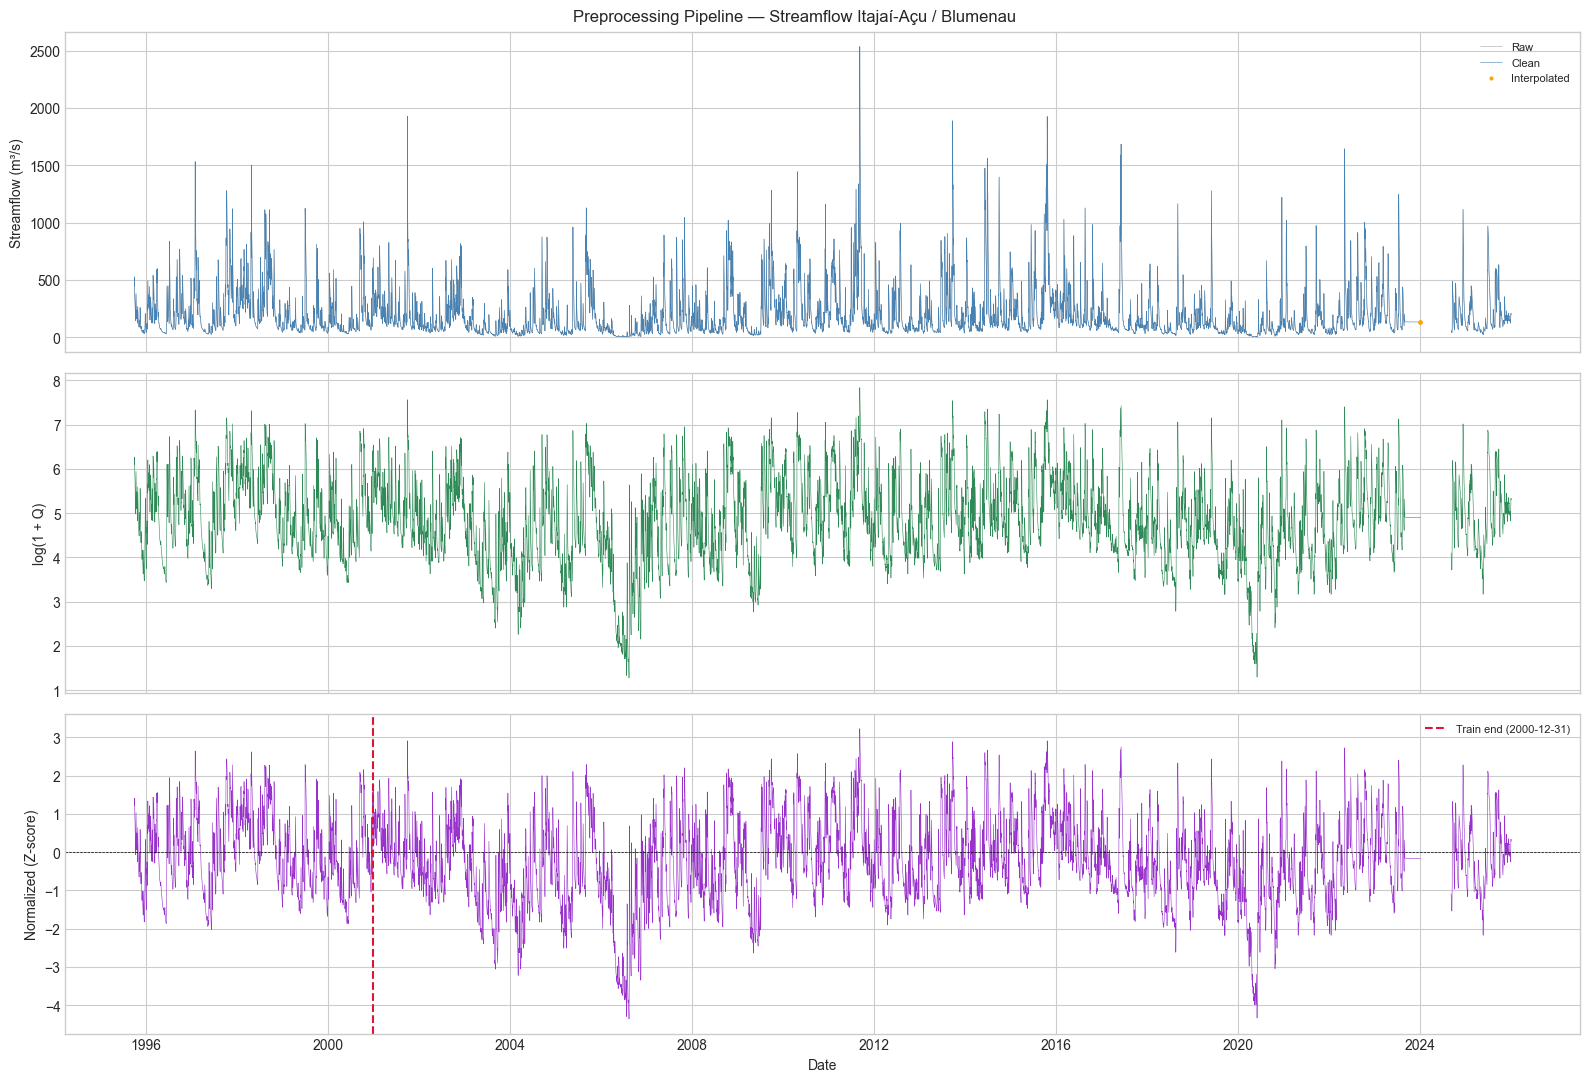

Residual gaps after interpolation: 1
       start        end  days
0 2024-01-04 2024-09-05   245


In [4]:
fig, axes = plt.subplots(3, 1, figsize=(16, 11), sharex=True)

Q_raw  = df_v['value'].rename('Raw (m³/s)')
Q_proc = df_processed['value'].rename('Clean (m³/s)')
Q_log  = df_processed['value_log'].rename('log(1+Q)')
Q_norm = df_processed['value_norm'].rename('Normalized (Z-score)')
interp = df_processed['interpolated']

# 1. Raw vs. Clean
axes[0].plot(Q_raw.index, Q_raw.values, lw=0.4, color='gray', alpha=0.7, label='Raw')
axes[0].plot(Q_proc.index, Q_proc.values, lw=0.4, color='steelblue', label='Clean')
if interp.sum() > 0:
    axes[0].scatter(interp[interp].index, Q_proc[interp],
                    c='orange', s=4, zorder=5, label='Interpolated')
axes[0].set_ylabel('Streamflow (m³/s)')
axes[0].legend(fontsize=8)

# 2. Log-transform
axes[1].plot(Q_log.index, Q_log.values, lw=0.4, color='seagreen')
axes[1].set_ylabel('log(1 + Q)')

# 3. Z-score normalized
axes[2].plot(Q_norm.index, Q_norm.values, lw=0.4, color='darkorchid')
axes[2].axhline(0, color='k', lw=0.5, ls='--')
axes[2].axvline(pd.Timestamp(TRAIN_END), color='crimson', lw=1.5, ls='--',
                label=f'Train end ({TRAIN_END})')
axes[2].set_ylabel('Normalized (Z-score)')
axes[2].legend(fontsize=8)

axes[-1].set_xlabel('Date')
fig.suptitle('Preprocessing Pipeline — Streamflow Itajaí-Açu / Blumenau', fontsize=12)
fig.tight_layout()
fig.savefig(FIGDIR / '16_preprocessing_pipeline.png', dpi=150, bbox_inches='tight')
plt.show()

# Gap statistics
from src.data.preprocessor import classify_gaps
gaps = classify_gaps(df_processed['value'])
print(f'Residual gaps after interpolation: {len(gaps)}')
if not gaps.empty:
    print(gaps.sort_values('days', ascending=False).head(10).to_string())

## 4. Caravan Dataset Generation

Converts local data to the format expected by OpenHydroNet.
Produces:
```
data/processed/Caravan-nc/
├── timeseries/
│   ├── csv/itajai/itajai_83500000.csv     ← hindcast + targets (load_as_csv: true)
│   └── netcdf/itajai/itajai_83500000.nc   ← reference / future zarr mode
└── attributes/itajai/
    ├── attributes_caravan_itajai.csv
    ├── attributes_hydroatlas_itajai.csv
    └── attributes_other_itajai.csv
```

In [5]:
processed_vazao_path = PROCESSED / f'{STATION}_vazao_processed.parquet'

print('Running caravan_formatter...')
paths = format_caravan(
    streamflow_parquet=processed_vazao_path,
    precipitation_parquet=precip_daily_path if (df_p is not None) else None,
    caravan_root=CARAVAN_ROOT,
)

print('\nGenerated files:')
for key, path in paths.items():
    size_kb = Path(path).stat().st_size / 1024
    print(f'  {key:20s}: {path.name} ({size_kb:.1f} KB)')

# Generate basin list file for the YAML
basins_txt = ROOT / 'configs/training/itajai_basins.txt'
generate_basins_list(CARAVAN_ROOT, out_path=basins_txt)
print(f'\nBasin list: {basins_txt}')
print(basins_txt.read_text())

Running caravan_formatter...

Generated files:
  timeseries_nc       : itajai_83500000.nc (213.1 KB)
  timeseries_csv      : itajai_83500000.csv (349.6 KB)
  attr_caravan        : attributes_caravan_itajai.csv (0.2 KB)
  attr_hydroatlas     : attributes_hydroatlas_itajai.csv (0.7 KB)
  attr_other          : attributes_other_itajai.csv (0.2 KB)

Basin list: ../../configs/training/itajai_basins.txt
itajai_83500000



## 5. Caravan Structure Validation

This is the **quality gate** before training.
All checks must be `True` before running `run train`.

In [6]:
print('Validating Caravan structure...')
checks = validate_caravan_structure(CARAVAN_ROOT)

all_ok = all(checks.values())
status_icon = '✓' if all_ok else '✗'

print(f'\nResult: {status_icon} {"PASSED" if all_ok else "FAILED"}')
print('-' * 40)
for check, result in checks.items():
    icon = '✓' if result else '✗  ← ISSUE'
    print(f'  {icon}  {check}')

if not all_ok:
    print('\nCorrections required before training:')
    for check, result in checks.items():
        if not result:
            print(f'  - {check}')

Validating Caravan structure...

Result: ✓ PASSED
----------------------------------------
  ✓  timeseries_csv_dir
  ✓  timeseries_csv_file
  ✓  csv_has_date
  ✓  csv_has_streamflow
  ✓  csv_has_precipitation
  ✓  timeseries_nc_dir
  ✓  timeseries_nc
  ✓  attributes_dir
  ✓  attr_caravan
  ✓  attr_hydroatlas
  ✓  attr_other
  ✓  nc_has_streamflow
  ✓  nc_date_complete


## 6. NetCDF Inspection

We open the generated file and verify:
- Correct dimensions and variables
- Continuous dates with no gaps in the index
- Values within expected physical bounds
- Temporal alignment between streamflow and precipitation

In [7]:
nc_path = CARAVAN_ROOT / 'timeseries/netcdf/itajai/itajai_83500000.nc'
ds = xr.open_dataset(nc_path)

print('=== NetCDF Info ===')
print(ds)

print('\n=== Dates ===')
dates = pd.DatetimeIndex(ds['date'].values)
print(f'Start:  {dates[0].date()}')
print(f'End:    {dates[-1].date()}')
print(f'Total:  {len(dates)} days')

# Check index continuity
gaps_in_index = pd.date_range(dates[0], dates[-1], freq='D').difference(dates)
print(f'Gaps in index: {len(gaps_in_index)}  (expected: 0)')

print('\n=== Streamflow ===')
q = ds['streamflow'].to_series()
print(f'  NaN:  {q.isna().sum()} ({q.isna().mean()*100:.1f}%)')
print(f'  min:  {q.min():.1f} m³/s')
print(f'  max:  {q.max():.1f} m³/s  (expected < 15000)')
print(f'  mean: {q.mean():.1f} m³/s')

if 'total_precipitation' in ds:
    p = ds['total_precipitation'].to_series()
    print('\n=== Precipitation ===')
    print(f'  NaN:  {p.isna().sum()} ({p.isna().mean()*100:.1f}%)')
    print(f'  max:  {p.max():.1f} mm/day')
    # Check temporal coverage coincident with streamflow
    both_valid = (~q.isna()) & (~p.isna())
    print(f'  Period with both valid: {both_valid.sum()} days')

ds.close()

=== NetCDF Info ===
<xarray.Dataset> Size: 263kB
Dimensions:              (date: 16436)
Coordinates:
  * date                 (date) datetime64[ns] 131kB 1981-01-01 ... 2025-12-31
Data variables:
    streamflow           (date) float32 66kB ...
    total_precipitation  (date) float32 66kB ...
Attributes:
    gauge_id:         itajai_83500000
    subdataset_name:  itajai
    created_by:       blumenau-flood-forecasting/caravan_formatter.py

=== Dates ===
Start:  1981-01-01
End:    2025-12-31
Total:  16436 days
Gaps in index: 0  (expected: 0)

=== Streamflow ===
  NaN:  5753 (35.0%)
  min:  2.6 m³/s
  max:  2534.1 m³/s  (expected < 15000)
  mean: 196.9 m³/s

=== Precipitation ===
  NaN:  365 (2.2%)
  max:  114.4 mm/day
  Period with both valid: 10318 days


## 7. Final Dataset Summary

Summary table documenting the state of the dataset before training.
Save this output as a reference alongside the training logs.

In [8]:
ds = xr.open_dataset(nc_path)
dates = pd.DatetimeIndex(ds['date'].values)
q = ds['streamflow'].to_series()

# Splits
train_mask = dates <= TRAIN_END
val_mask   = (dates > TRAIN_END) & (dates <= '2010-12-31')
test_mask  = dates > '2010-12-31'

summary = {
    'Total period':            f'{dates[0].date()} → {dates[-1].date()}',
    'Total days':              len(dates),
    'Streamflow: total coverage':  f'{q.notna().mean()*100:.1f}%',
    'Streamflow: train coverage':  f'{q[train_mask].notna().mean()*100:.1f}%',
    'Streamflow: val coverage':    f'{q[val_mask].notna().mean()*100:.1f}%',
    'Streamflow: test coverage':   f'{q[test_mask].notna().mean()*100:.1f}%',
    'Streamflow: historical max':  f'{q.max():.0f} m³/s',
    'Normalization: mean':         f'{norm_stats["mean"]:.4f}',
    'Normalization: std':          f'{norm_stats["std"]:.4f}',
    'Normalization: train_end':    norm_stats['train_end'],
    'Caravan: all checks':         '✓ OK' if all(checks.values()) else '✗ SEE ABOVE',
}

if 'total_precipitation' in ds:
    p = ds['total_precipitation'].to_series()
    summary['Precipitation: total coverage'] = f'{p.notna().mean()*100:.1f}%'

print('=' * 52)
print('  DATASET SUMMARY — READY FOR TRAINING')
print('=' * 52)
for k, v in summary.items():
    print(f'  {k:<35s} {v}')
print('=' * 52)

# Save as JSON
summary_path = PROCESSED / 'dataset_summary.json'
with open(summary_path, 'w') as f:
    json.dump(summary, f, indent=2)
print(f'\nSaved: {summary_path}')

ds.close()

  DATASET SUMMARY — READY FOR TRAINING
  Total period                        1981-01-01 → 2025-12-31
  Total days                          16436
  Streamflow: total coverage          65.0%
  Streamflow: train coverage          26.3%
  Streamflow: val coverage            100.0%
  Streamflow: test coverage           93.3%
  Streamflow: historical max          2534 m³/s
  Normalization: mean                 5.0465
  Normalization: std                  0.8644
  Normalization: train_end            2000-12-31
  Caravan: all checks                 ✓ OK
  Precipitation: total coverage       97.8%

Saved: ../../data/processed/dataset_summary.json


## 8. Coverage Plot by Split

Temporal visualization showing what the model "sees" in each phase.

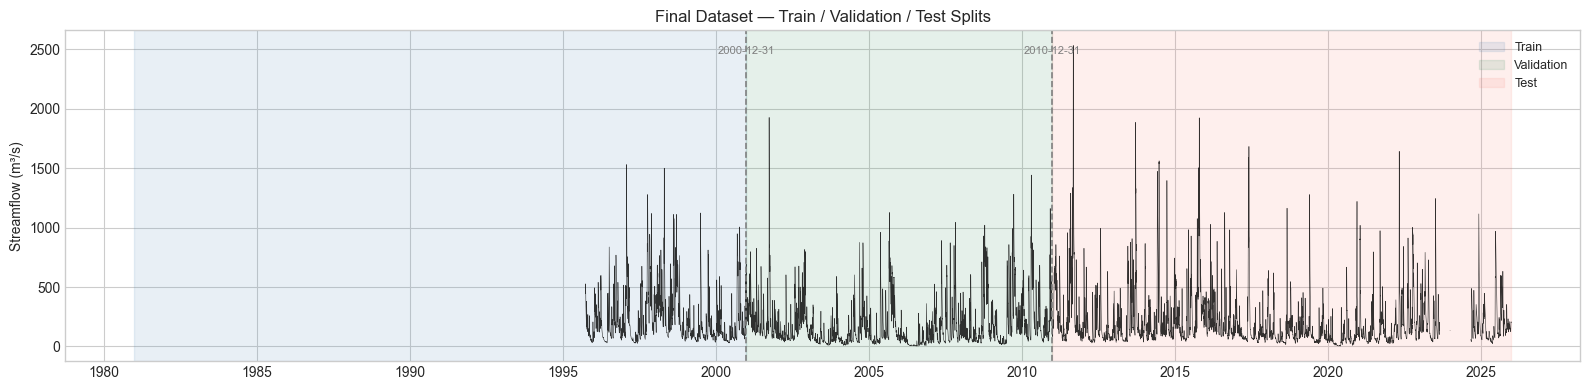

In [9]:
ds = xr.open_dataset(nc_path)
q = ds['streamflow'].to_series()
dates = q.index

fig, ax = plt.subplots(figsize=(16, 4))

TRAIN_END_DT = pd.Timestamp(TRAIN_END)
VAL_END_DT   = pd.Timestamp('2010-12-31')

# Shade splits
ax.axvspan(dates[0], TRAIN_END_DT, alpha=0.12, color='steelblue', label='Train')
ax.axvspan(TRAIN_END_DT, VAL_END_DT, alpha=0.12, color='seagreen', label='Validation')
ax.axvspan(VAL_END_DT, dates[-1], alpha=0.12, color='salmon', label='Test')

ax.plot(q.index, q.values, lw=0.4, color='k', alpha=0.8)

# Split boundary lines
for dt, label in [(TRAIN_END_DT, TRAIN_END), (VAL_END_DT, '2010-12-31')]:
    ax.axvline(dt, color='gray', lw=1.2, ls='--')
    ax.text(dt, ax.get_ylim()[1]*0.95 if ax.get_ylim()[1] > 0 else 1000,
            label, ha='center', va='top', fontsize=8, color='gray')

ax.set_ylabel('Streamflow (m³/s)')
ax.set_title('Final Dataset — Train / Validation / Test Splits', fontsize=12)
ax.legend(fontsize=9, loc='upper right')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

fig.tight_layout()
fig.savefig(FIGDIR / '17_dataset_splits.png', dpi=150, bbox_inches='tight')
plt.show()
ds.close()